# Notebook 3 - Cohort Retention Analysis

**Goal** - group subscribers by the month they registered and track what percentage of each cohort remained active over time.

Reads from `master.csv`. Output: a retention heatmap across 27 monthly cohorts (2015–2017).

## Load data and assign cohorts

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

PROCESSED = Path(r"C:\kkbox-retention-analytics\data\processed")

cols = ['msno', 'registration_init_time', 'last_active_date']
master = pd.read_csv(PROCESSED / "master.csv", usecols=cols, parse_dates=['registration_init_time', 'last_active_date'])

master = master.dropna(subset=['registration_init_time', 'last_active_date'])

master['cohort_month'] = master['registration_init_time'].dt.to_period('M')

print(f"Subscribers loaded:  {master.shape[0]:,}")
print(f"Cohort range:        {master['cohort_month'].min()} → {master['cohort_month'].max()}")
print(f"Unique cohorts:      {master['cohort_month'].nunique()}")

Subscribers loaded:  955,126
Cohort range:        2004-03 → 2017-03
Unique cohorts:      157


## Calculate months active per subscriber

Measured from first to last activity date in the user logs. Not the same as subscription payment status.

In [2]:
master['months_active'] = (
    (master['last_active_date'] - master['registration_init_time'])
    .dt.days
    .floordiv(30)
    .clip(lower=0)
)

master = master[master['cohort_month'] >= pd.Period('2015-01', 'M')]

print(f"Subscribers after 2015 filter: {master.shape[0]:,}")
print(f"Cohorts:                       {master['cohort_month'].nunique()}")
print(f"\nMonths active distribution:")
print(master['months_active'].describe().round(1))

Subscribers after 2015 filter: 428,879
Cohorts:                       27

Months active distribution:
count    428879.0
mean         11.4
std           7.0
min           0.0
25%           5.0
50%          12.0
75%          17.0
max          27.0
Name: months_active, dtype: float64


## Build cohort retention matrix

For each cohort, what percentage of the original group was still active at each month offset. Month 0 is always 100% by definition.

In [3]:
cohort_sizes = master.groupby('cohort_month')['msno'].count()
max_months   = int(master['months_active'].max())

retention_dict = {}
for n in range(max_months + 1):
    active_at_n        = (master[master['months_active'] >= n]
                          .groupby('cohort_month')['msno']
                          .count())
    retention_dict[n]  = active_at_n / cohort_sizes

cohort_pivot = pd.DataFrame(retention_dict)
cohort_pivot.index = cohort_pivot.index.astype(str)

print(f"Retention matrix shape: {cohort_pivot.shape}")
print(f"\nFirst 3 cohorts, first 6 months:")
print(cohort_pivot.iloc[:3, :6].round(3))

Retention matrix shape: (27, 28)

First 3 cohorts, first 6 months:
                0      1      2      3      4      5
cohort_month                                        
2015-01       1.0  0.996  0.995  0.994  0.992  0.991
2015-02       1.0  0.996  0.996  0.995  0.994  0.992
2015-03       1.0  0.995  0.994  0.992  0.990  0.989


## Retention heatmap

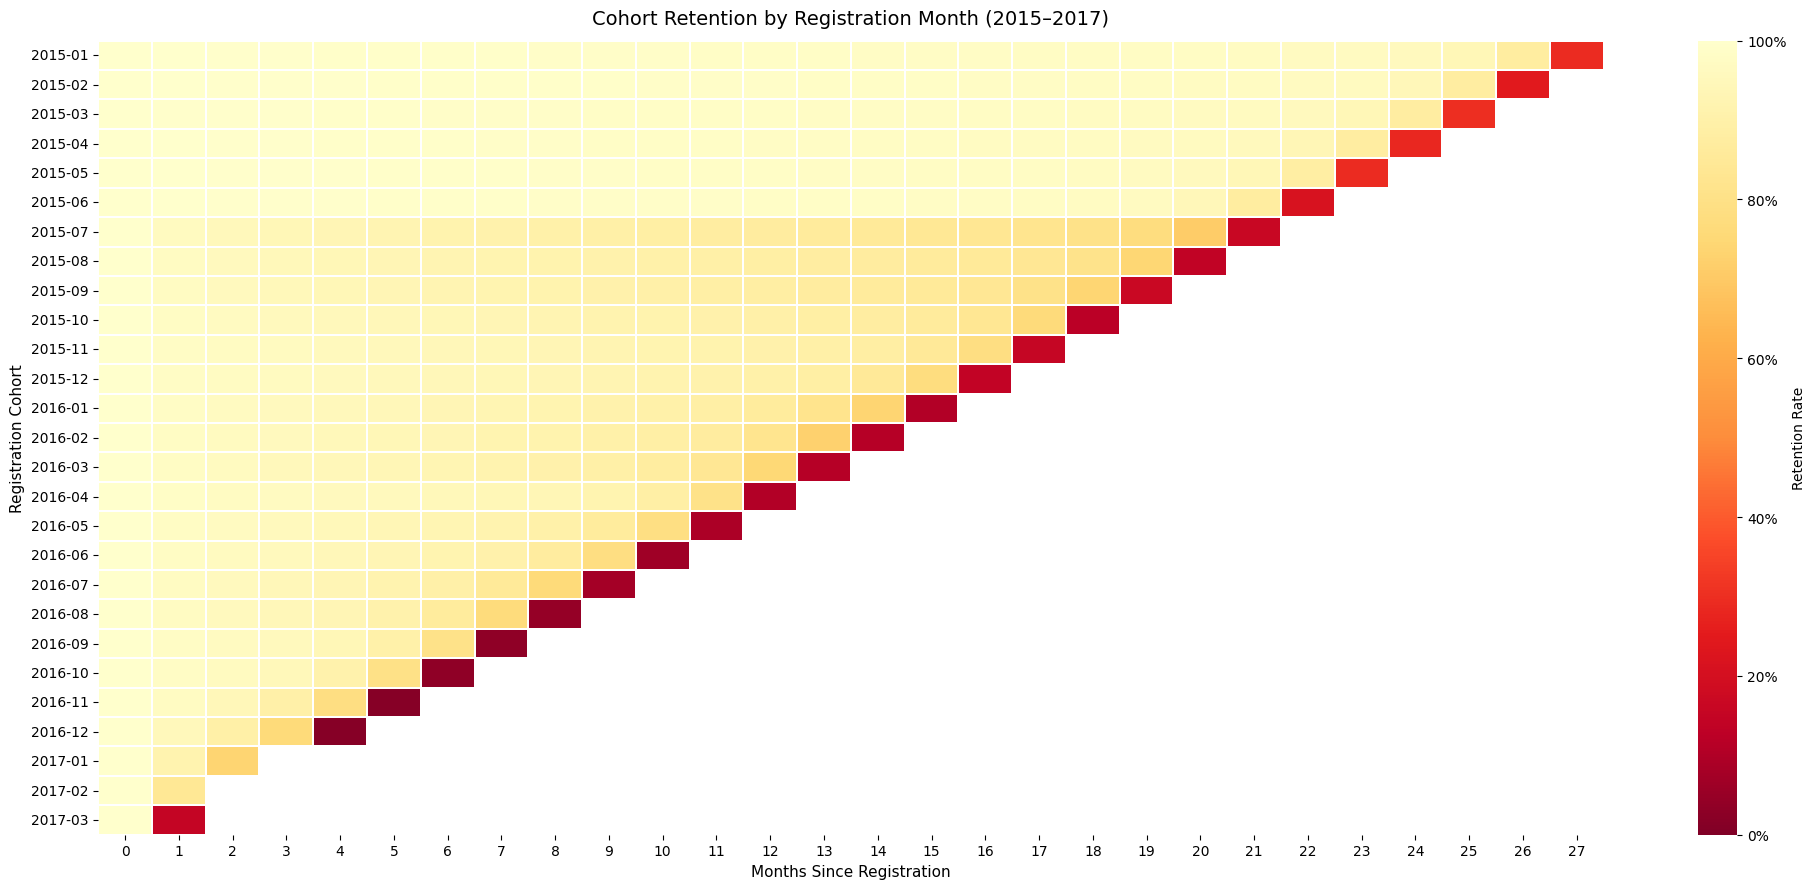

Early vs late cohort retention at month 6:
cohort_month
2016-10    0.033743
2016-09    0.805387
2016-08    0.866078
2016-07    0.895651
2015-07    0.913959
Name: 6, dtype: float64
cohort_month
2016-11   NaN
2016-12   NaN
2017-01   NaN
2017-02   NaN
2017-03   NaN
Name: 6, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 9))

sns.heatmap(
    cohort_pivot,
    cmap='YlOrRd_r',
    vmin=0,
    vmax=1,
    linewidths=0.3,
    cbar_kws={'label': 'Retention Rate', 'format': '{x:.0%}'}
)

plt.title('Cohort Retention by Registration Month (2015–2017)', fontsize=14, pad=12)
plt.xlabel('Months Since Registration', fontsize=11)
plt.ylabel('Registration Cohort', fontsize=11)
plt.tight_layout()
plt.show()

print("Early vs late cohort retention at month 6:")
print(cohort_pivot[6].sort_values().head(5))
print(cohort_pivot[6].sort_values().tail(5))

## Conclusion

All 27 cohorts follow similar retention curves — no single registration period stands out as dramatically better or worse. Product experience has been consistent across 2015–2017.

The dark diagonal cells on the right edge of each cohort row are a data cutoff artefact (April 2017 observation boundary), not a product event.

Next: notebook 4 formalises retention patterns using Kaplan-Meier survival curves.